In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from sklearn.model_selection import train_test_split

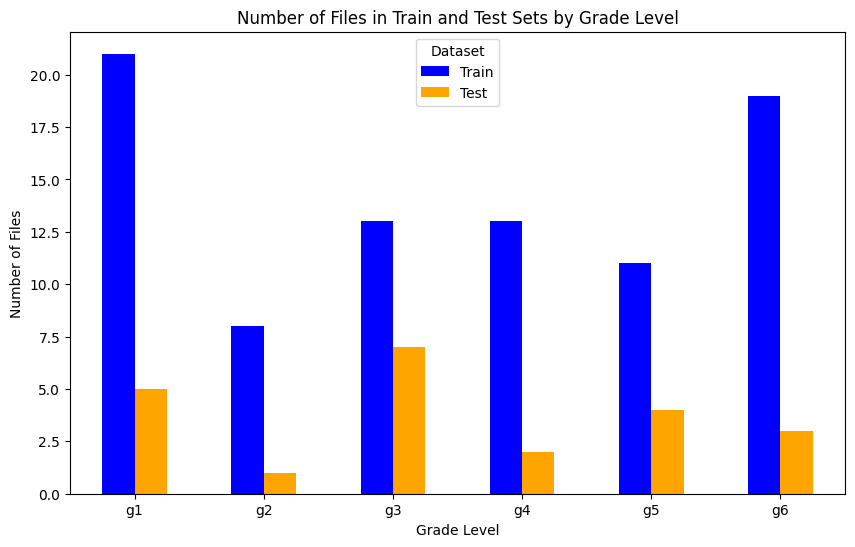

In [12]:
base_dir = "../txt/utf"
test_size=0.2
random_seed=42

all_files = []

for root, _, files in os.walk(base_dir):
    grade = os.path.basename(root)
    for file in files:
        if file.endswith(".txt"):
            all_files.append((os.path.join(root, file), grade))

random.seed(random_seed)
random.shuffle(all_files)
train_files, test_files = train_test_split(all_files, test_size=test_size, random_state=random_seed)

train_grades = [grade for _, grade in train_files]
test_grades = [grade for _, grade in test_files]

train_grade_counts = pd.Series(train_grades).value_counts().sort_index()
test_grade_counts = pd.Series(test_grades).value_counts().sort_index()

grade_data = pd.DataFrame({
    'Train': train_grade_counts,
    'Test': test_grade_counts
}).fillna(0)  # Fill NaN with 0 for missing grade levels

grade_data.plot(kind='bar', figsize=(10, 6), color=['blue', 'orange'])
plt.title('Number of Files in Train and Test Sets by Grade Level')
plt.xlabel('Grade Level')
plt.ylabel('Number of Files')
plt.xticks(rotation=0)
plt.legend(title='Dataset')
plt.show()


In [27]:
df = pd.read_csv('../tables/dataset.csv')
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   text_num  grade_level  stride_len  stride_index  n_gram  noun_tr  verb_tr  \
0        44            4           1             0   isang      0.0      0.0   
1        44            4           1             1    araw      1.0      0.0   
2        44            4           1             2     may      0.0      1.0   
3        44            4           1             3   isang      0.0      0.0   
4        44            4           1             4  maliit      0.0      0.0   

   type_tr  lex_density  lex_foreign   sent_len  word_len  word_num  syll_num  \
0      1.0          0.0          0.0  14.533333       5.0       NaN       1.0   
1      1.0          1.0          0.0  14.533333       4.0       NaN       1.0   
2      1.0          1.0          0.0  14.533333       3.0       NaN       1.0   
3      1.0          0.0          0.0  14.533333       5.0       NaN       1.0   
4      1.0          1.0          0.0  14.533333       6.0       NaN       2.0   

   

In [28]:
# Feature data type
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195438 entries, 0 to 195437
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   text_num      195438 non-null  int64  
 1   grade_level   195438 non-null  int64  
 2   stride_len    195438 non-null  int64  
 3   stride_index  195438 non-null  int64  
 4   n_gram        195438 non-null  object 
 5   noun_tr       195438 non-null  float64
 6   verb_tr       195438 non-null  float64
 7   type_tr       195438 non-null  float64
 8   lex_density   195438 non-null  float64
 9   lex_foreign   195438 non-null  float64
 10  sent_len      195438 non-null  float64
 11  word_len      195438 non-null  float64
 12  word_num      0 non-null       float64
 13  syll_num      195438 non-null  float64
 14  poly_num      195438 non-null  int64  
dtypes: float64(9), int64(5), object(1)
memory usage: 22.4+ MB
None


In [29]:
df = df.drop('word_num', axis=1)
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
text_num        0
grade_level     0
stride_len      0
stride_index    0
n_gram          0
noun_tr         0
verb_tr         0
type_tr         0
lex_density     0
lex_foreign     0
sent_len        0
word_len        0
syll_num        0
poly_num        0
dtype: int64


In [30]:
# Summary statistics of numerical columns
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
            text_num    grade_level     stride_len   stride_index  \
count  195438.000000  195438.000000  195438.000000  195438.000000   
mean       33.897364       4.057993       2.372635    1098.472354   
std        22.154898       1.607520       3.278602    1492.189452   
min         4.000000       1.000000       1.000000       0.000000   
25%        18.000000       3.000000       1.000000     203.000000   
50%        26.000000       4.000000       2.000000     563.000000   
75%        46.000000       6.000000       3.000000    1152.000000   
max       104.000000       6.000000     164.000000    6700.000000   

             noun_tr        verb_tr        type_tr    lex_density  \
count  195438.000000  195438.000000  195438.000000  195438.000000   
mean        0.384735       0.102631       0.991409       0.600403   
std         0.401223       0.230399       0.055892       0.365689   
min         0.000000       0.000000       0.127800       0.000000   
25%         

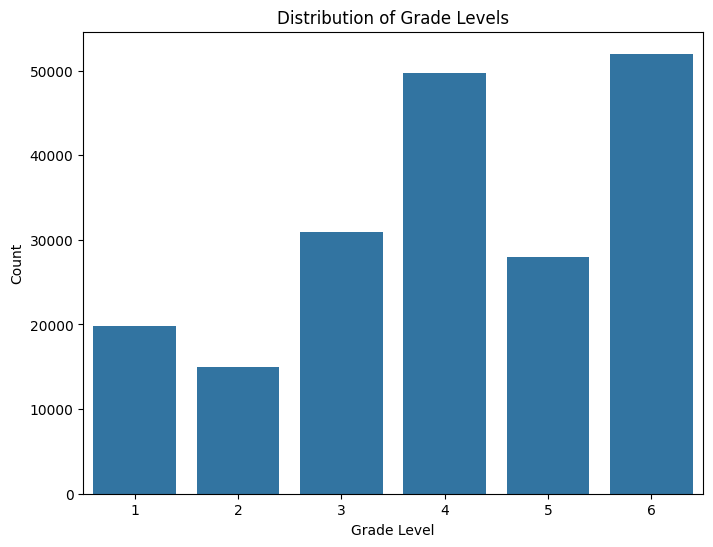

In [31]:
# Visualize the distribution of the dependent variable (grade_level)
plt.figure(figsize=(8, 6))
sns.countplot(x='grade_level', data=df)
plt.title('Distribution of Grade Levels')
plt.xlabel('Grade Level')
plt.ylabel('Count')
plt.show()

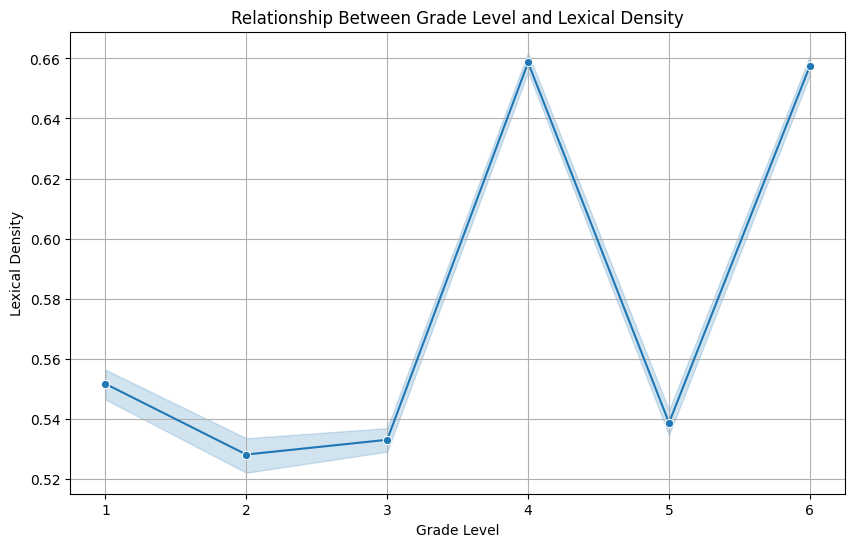

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='grade_level', y='lex_density', data=df, marker='o')
plt.title('Relationship Between Grade Level and Lexical Density')
plt.xlabel('Grade Level')
plt.ylabel('Lexical Density')
plt.grid(True)
plt.show()